<a href="https://colab.research.google.com/github/rajeshtikaddar/Internship/blob/main/AI_based_IDS_Prototype_Day_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**AI based IDS Prototype**

**Importing Libraries**

In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


import matplotlib.pyplot as plt
import seaborn as sns

**Sample Data**

In [8]:
data = {
    "User":["U1","U2","U3","U4","U5","U6","U7","U8","U9","U10"],
    "Login_Hour":[9,2,11,1,14,3,10,23,8,4],
    "Failed_Attempts":[0,7,1,10,0,8,0,12,1,9],
    "Location":["Office","Unknown","Office","Unknown",
                "Office","Unknown","Office","Unknown",
                "Office","Unknown"],
    "Intrusion":[0,1,0,1,0,1,0,1,0,1]
}

df = pd.DataFrame(data)

df.head()

,User,Login_Hour,Failed_Attempts,Location,Intrusion
0,U1,9,0,Office,0
1,U2,2,7,Unknown,1
2,U3,11,1,Office,0
3,U4,1,10,Unknown,1
4,U5,14,0,Office,0


**Data Preprocessing**

In [9]:
encoder = LabelEncoder()
df["Location"] = encoder.fit_transform(df["Location"])

df.head()

,User,Login_Hour,Failed_Attempts,Location,Intrusion
0,U1,9,0,0,0
1,U2,2,7,1,1
2,U3,11,1,0,0
3,U4,1,10,1,1
4,U5,14,0,0,0


**Feature Selection**

In [10]:
X = df[["Login_Hour","Failed_Attempts","Location"]]
y = df["Intrusion"]

**Train-Test Split**

In [11]:
X_train,X_test, y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )


**Build AI Model**

In [12]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
    )
model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

**Intrusion Detection**

In [13]:
predictions = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,predictions))
print("\nClasssification report : ")
print(classification_report(y_test,predictions))


Accuracy: 1.0

Classsification report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



**Test New Users**

In [15]:
new_users = pd.DataFrame({
    "Login_Hour":[10,2,13],
    "Failed_Attempts":[0,8,1],
    "Location":[0,1,0]
})

results = new_users.copy()

results["Prediction"] = model.predict(new_users)

results["Prediction"] = results["Prediction"].map({
    0:"Normal",
    1:"Intrusion"
})

results

,Login_Hour,Failed_Attempts,Location,Prediction
0,10,0,0,Normal
1,2,8,1,Intrusion
2,13,1,0,Normal


**Generate Risk Levels**

In [20]:
def risk_level(row):
   if row["Prediction"] == "Intrusion":
        return "High"
   return "Low"

results["Risk_Level"] = results.apply(
    risk_level,
    axis=1
)

results

,Login_Hour,Failed_Attempts,Location,Prediction,Risk_Level
0,10,0,0,Normal,Low
1,2,8,1,Intrusion,High
2,13,1,0,Normal,Low


**Generate Alerts**

In [21]:
for index, row in results.iterrows():

    if row["Prediction"] == "Intrusion":

        print(
            f"ALERT: Intrusion Detected for Record {index+1}"
        )

ALERT: Intrusion Detected for Record 2


**Visualization 1 (intrusion count)**

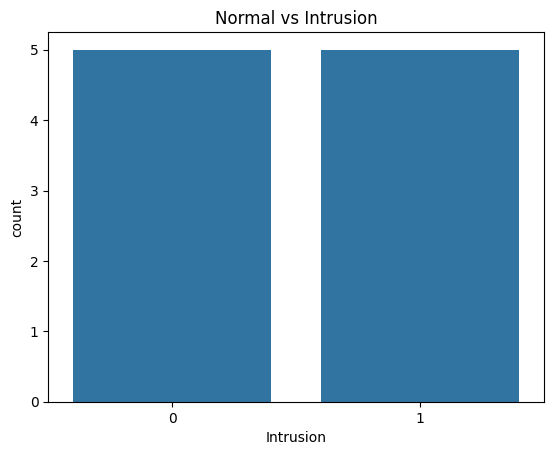

In [22]:
sns.countplot(
    x="Intrusion",
    data=df
)

plt.title("Normal vs Intrusion")
plt.show()

**Visualization 2 (failed attempts)**

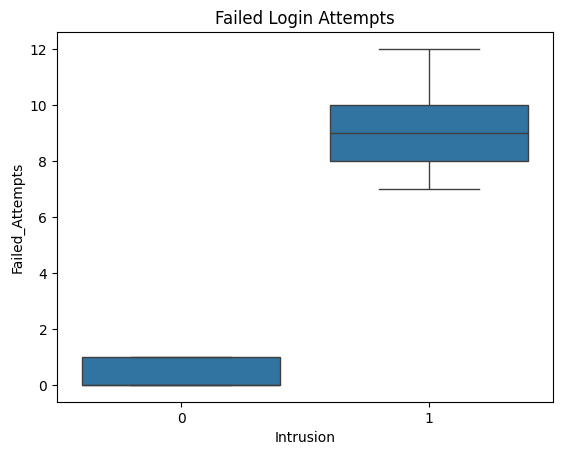

In [23]:
sns.boxplot(
    x="Intrusion",
    y="Failed_Attempts",
    data=df
)

plt.title("Failed Login Attempts")
plt.show()
